<a href="https://colab.research.google.com/github/SintiyaMaharani34/zomato-delivery-performance-analysis-/blob/main/02_EDA_Zomato_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning
import warnings
warnings.filterwarnings('ignore')

# Display Setting
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Visualization Style
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================
# Upload Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving zomato_delivery_clean.csv to zomato_delivery_clean.csv


In [ ]:
# ==========================================
# Load Dataset
# ==========================================

import io

df = pd.read_csv(io.BytesIO(next(iter(uploaded.values()))))

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# ==========================================
# Rename Columns
# ==========================================

df = df.rename(columns={
    'Time_taken (min)': 'Delivery_Time'
})

df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Delivery_Time',
       'Order_Datetime', 'Pickup_Datetime', 'Preparation_Time',
       'Delivery_Distance_km', 'Order_Hour', 'Day_of_Week', 'Is_Weekend',
       'Time_of_Day'],
      dtype='object')

In [ ]:
# ==========================================
# Dataset Overview
# ==========================================

print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


DATASET OVERVIEW
Rows    : 43697
Columns : 28


In [ ]:
display(df.head())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Delivery_Time,Order_Datetime,Pickup_Datetime,Preparation_Time,Delivery_Distance_km,Order_Hour,Day_of_Week,Is_Weekend,Time_of_Day
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,2022-02-12 21:55:00,2022-02-12 22:10:00,15.0,10.280582,21,Saturday,Weekend,Night
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,2022-02-13 14:55:00,2022-02-13 15:05:00,10.0,6.242319,14,Sunday,Weekend,Afternoon
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,2022-03-04 17:30:00,2022-03-04 17:40:00,10.0,13.787860,17,Friday,Weekday,Evening
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2022-02-13 09:20:00,2022-02-13 09:30:00,10.0,2.930258,9,Sunday,Weekend,Morning
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,2022-02-14 19:50:00,2022-02-14 20:05:00,15.0,19.396618,19,Monday,Weekday,Evening


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43697 entries, 0 to 43696
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           43697 non-null  object 
 1   Delivery_person_ID           43697 non-null  object 
 2   Delivery_person_Age          43697 non-null  float64
 3   Delivery_person_Ratings      43697 non-null  float64
 4   Restaurant_latitude          43697 non-null  float64
 5   Restaurant_longitude         43697 non-null  float64
 6   Delivery_location_latitude   43697 non-null  float64
 7   Delivery_location_longitude  43697 non-null  float64
 8   Order_Date                   43697 non-null  object 
 9   Time_Orderd                  43697 non-null  object 
 10  Time_Order_picked            43697 non-null  object 
 11  Weather_conditions           43697 non-null  object 
 12  Road_traffic_density         43697 non-null  object 
 13  Vehicle_conditio

None

In [ ]:
display(df.describe())

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Delivery_Time,Preparation_Time,Delivery_Distance_km,Order_Hour
count,43697.000000,43697.000000,43697.000000,43697.000000,43697.000000,43697.000000,43697.000000,43697.000000,43697.000000,43697.000000,43697.000000,43697.000000
mean,29.556743,4.635689,17.382547,70.733840,17.446146,70.797439,1.000732,0.749571,26.297480,9.989931,9.733440,17.423530
std,5.748297,0.312973,7.336266,21.168010,7.337620,21.168183,0.816459,0.567782,9.377103,4.087746,5.604191,4.817972
min,20.000000,2.500000,0.000000,0.000000,0.010000,0.010000,0.000000,0.000000,10.000000,5.000000,1.465067,0.000000
25%,25.000000,4.500000,12.934179,73.170283,12.985996,73.275081,0.000000,0.000000,19.000000,5.000000,4.663412,15.000000
50%,30.000000,4.700000,18.554382,75.898497,18.632718,75.997522,1.000000,1.000000,26.000000,10.000000,9.220209,19.000000
75%,35.000000,4.900000,22.732225,78.044095,22.783839,78.099117,2.000000,1.000000,32.000000,15.000000,13.681416,21.000000
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,2.000000,3.000000,54.000000,15.000000,20.969489,23.000000


![image.png]()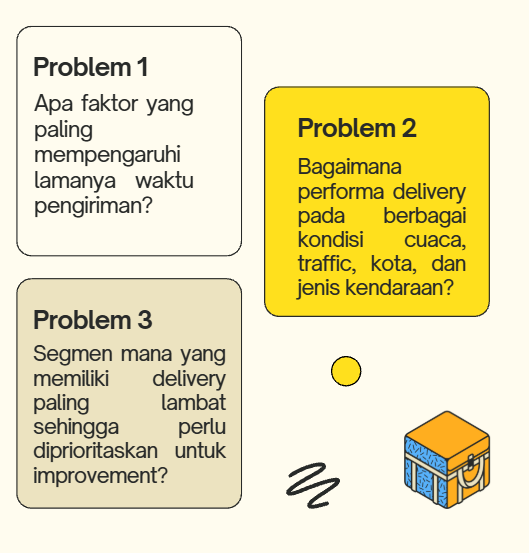

# Univariate Analysis

This section explores the distribution of individual variables to understand their characteristics before analyzing relationships between variables.

In [ ]:
# ==========================================
# Numerical Features
# ==========================================

numerical_cols = [
    'Delivery_Time',
    'Preparation_Time',
    'Delivery_Distance_km',
    'Delivery_person_Age',
    'Delivery_person_Ratings'
]

In [ ]:
# ==========================================
# Summary Statistics
# ==========================================

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Delivery_Time,43697.0,26.297480,9.377103,10.000000,19.000000,26.000000,32.000000,54.000000
Preparation_Time,43697.0,9.989931,4.087746,5.000000,5.000000,10.000000,15.000000,15.000000
Delivery_Distance_km,43697.0,9.733440,5.604191,1.465067,4.663412,9.220209,13.681416,20.969489
Delivery_person_Age,43697.0,29.556743,5.748297,20.000000,25.000000,30.000000,35.000000,39.000000
Delivery_person_Ratings,43697.0,4.635689,0.312973,2.500000,4.500000,4.700000,4.900000,5.000000


In [ ]:
# ==========================================
# Function for Numerical Distribution
# ==========================================

def plot_numeric_distribution(column):

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(14,5)
    )

    sns.histplot(
        df[column],
        bins=30,
        kde=True,
        ax=ax[0]
    )

    ax[0].set_title(f'Distribution of {column}')

    sns.boxplot(
        x=df[column],
        ax=ax[1]
    )

    ax[1].set_title(f'Boxplot of {column}')

    plt.tight_layout()
    plt.show()

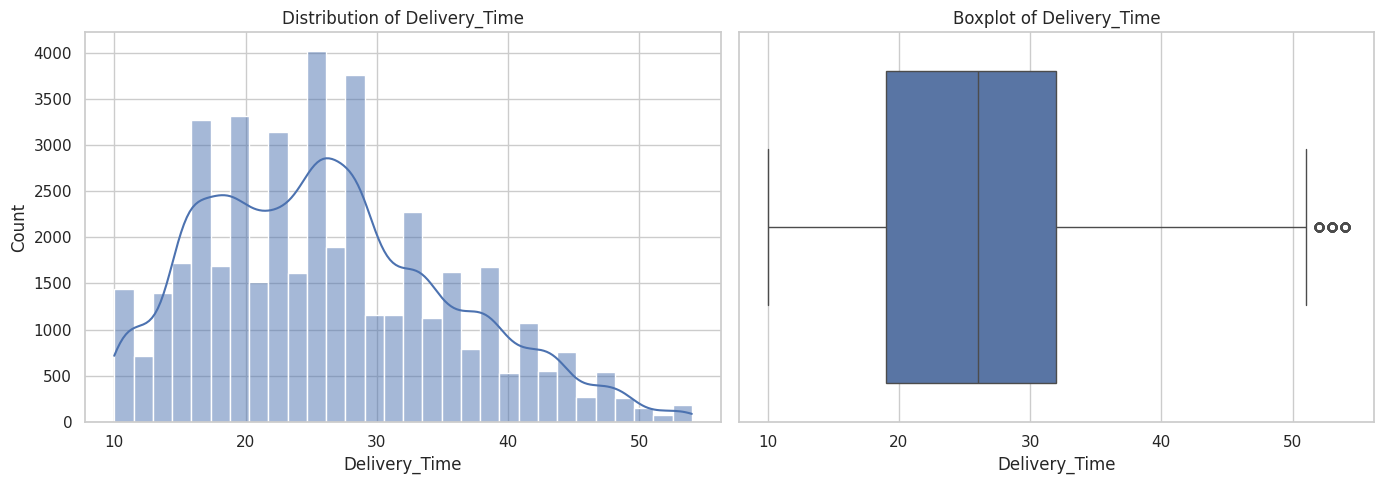

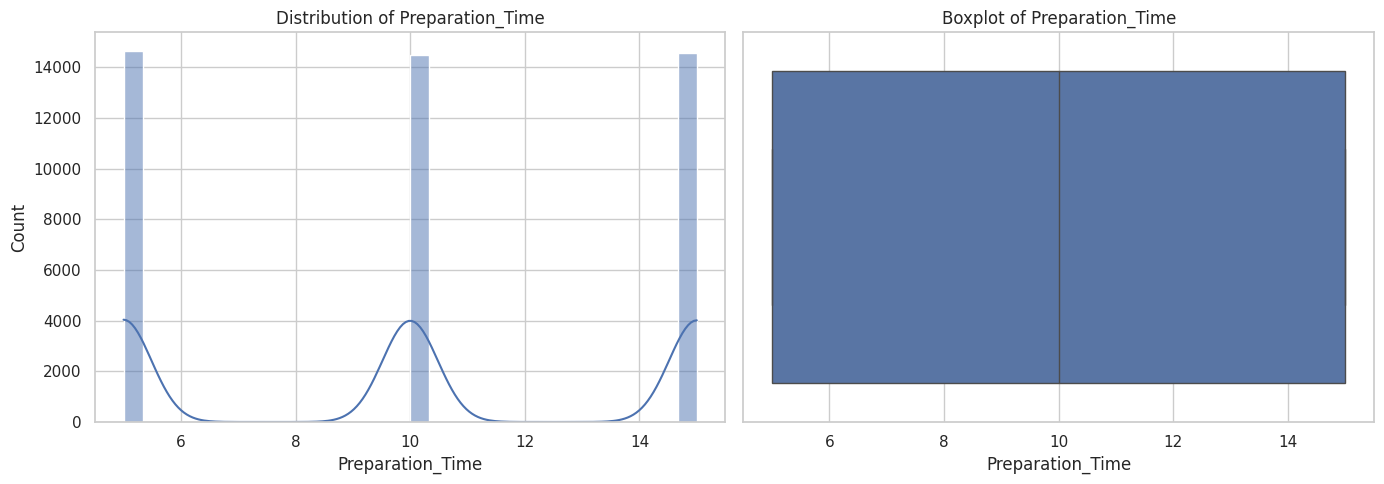

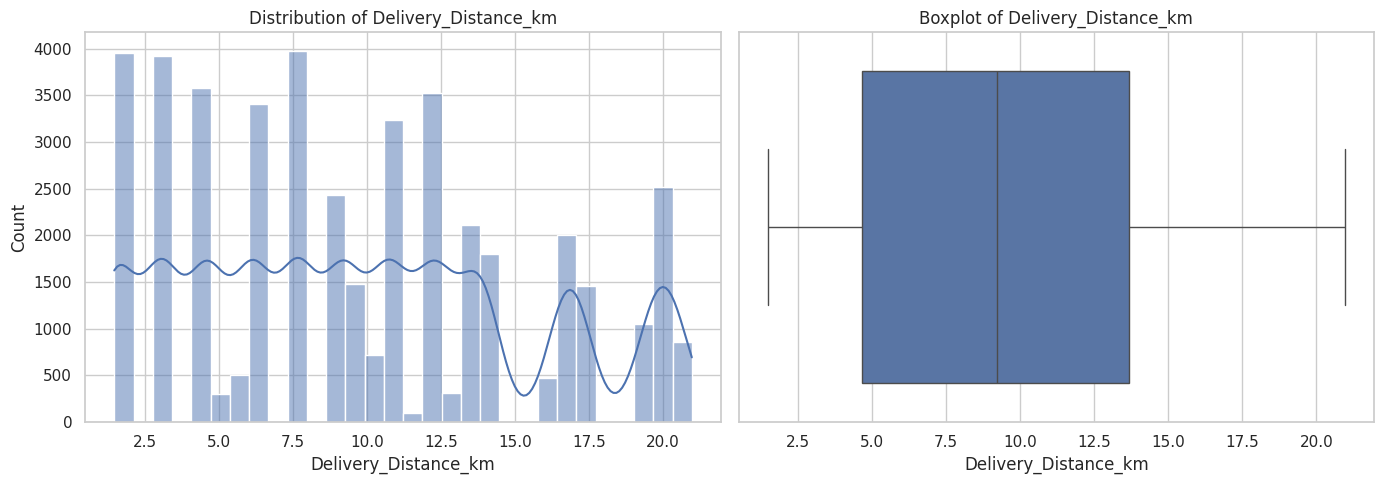

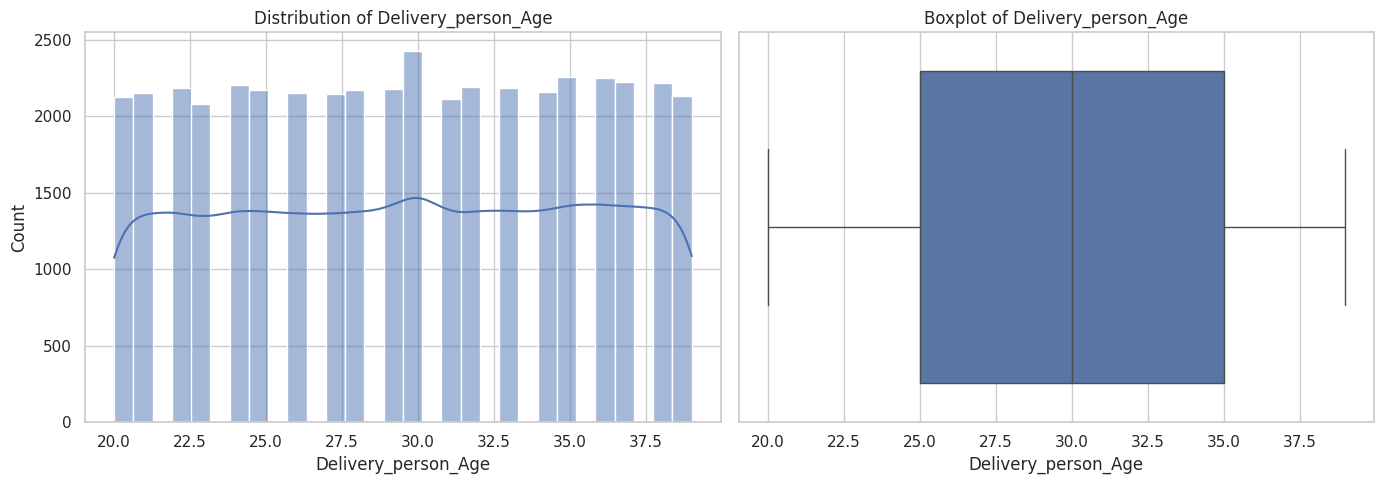

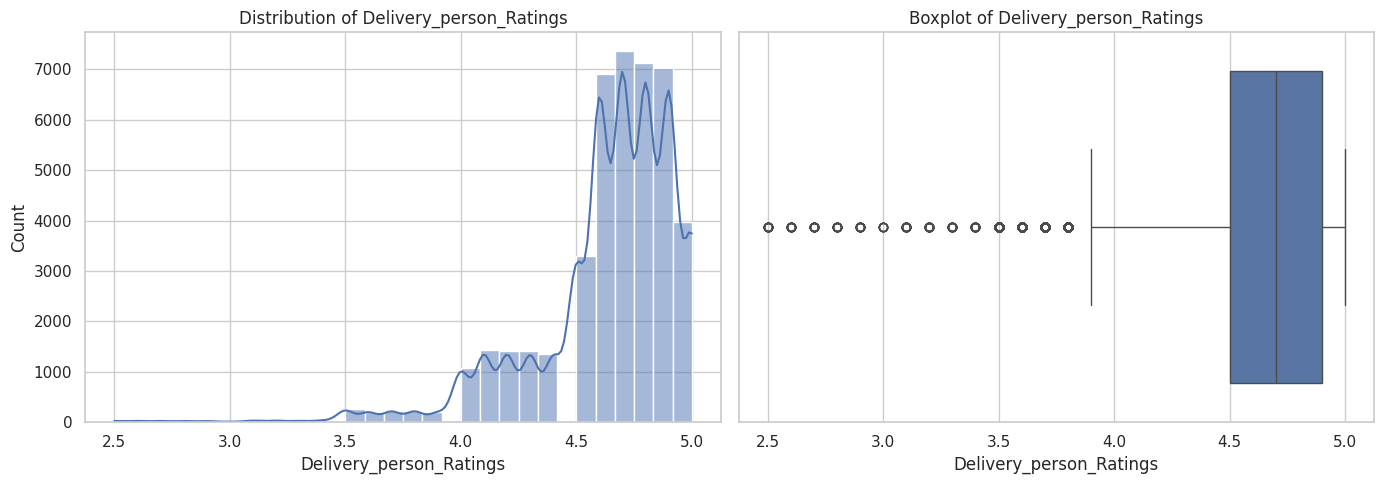

In [ ]:
for col in numerical_cols:
    plot_numeric_distribution(col)

## Key Findings

- Delivery Time shows a slight right-skewed distribution, indicating occasional delivery delays.
- Preparation Time is standardized into three operational categories (5, 10, and 15 minutes).
- Delivery Distance mainly falls within short-to-medium delivery ranges.
- Courier Age is evenly distributed across the workforce.
- Courier Ratings are consistently high, with most ratings above 4.5.

In [ ]:
# ==========================================
# Categorical Features
# ==========================================

categorical_cols = [
    'Weather_conditions',
    'Road_traffic_density',
    'City',
    'Type_of_vehicle',
    'Type_of_order',
    'Festival',
    'Day_of_Week',
    'Time_of_Day',
    'Is_Weekend'
]

In [ ]:
# ==========================================
# Summary Statistics
# ==========================================

df[categorical_cols].describe().T

,count,unique,top,freq
Weather_conditions,43697,6,Fog,7450
Road_traffic_density,43697,4,Low,15002
City,43697,3,Metropolitian,33825
Type_of_vehicle,43697,3,motorcycle,25531
Type_of_order,43697,4,Snack,11055
Festival,43697,2,No,42840
Day_of_Week,43697,7,Wednesday,6804
Time_of_Day,43697,4,Evening,17828
Is_Weekend,43697,2,Weekday,31660


In [ ]:
# ==========================================
# Function for Categorical Distribution
# ==========================================

def plot_categorical_distribution(column):

    plt.figure(figsize=(8,5))

    order = df[column].value_counts().index

    ax = sns.countplot(
        data=df,
        x=column,
        order=order
    )

    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=30)

    # tampilkan jumlah di atas bar
    for container in ax.containers:
        ax.bar_label(container)

    plt.tight_layout()
    plt.show()

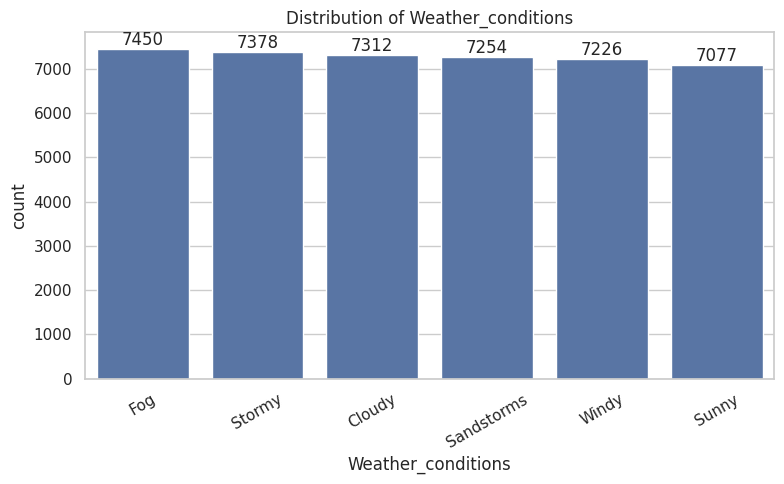

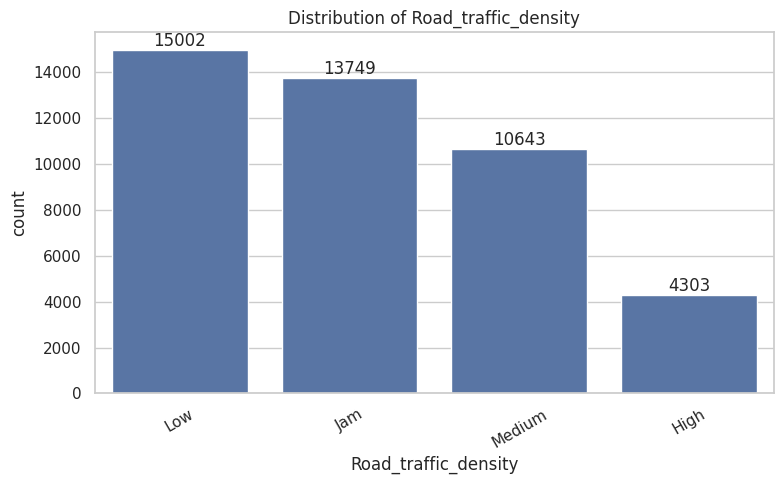

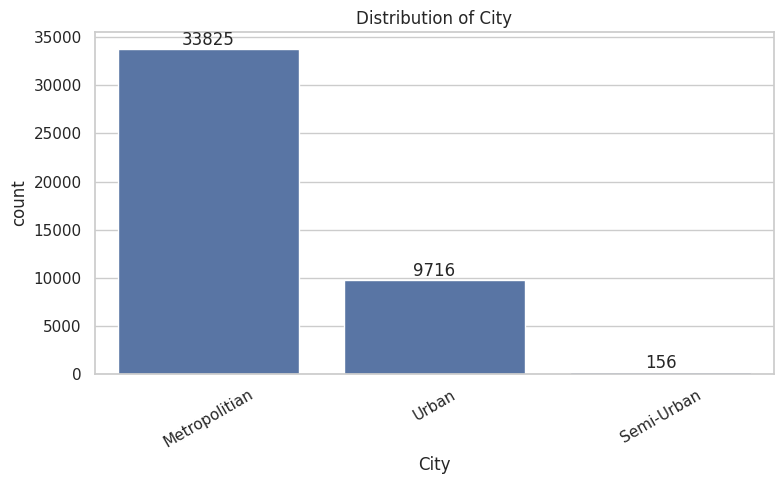

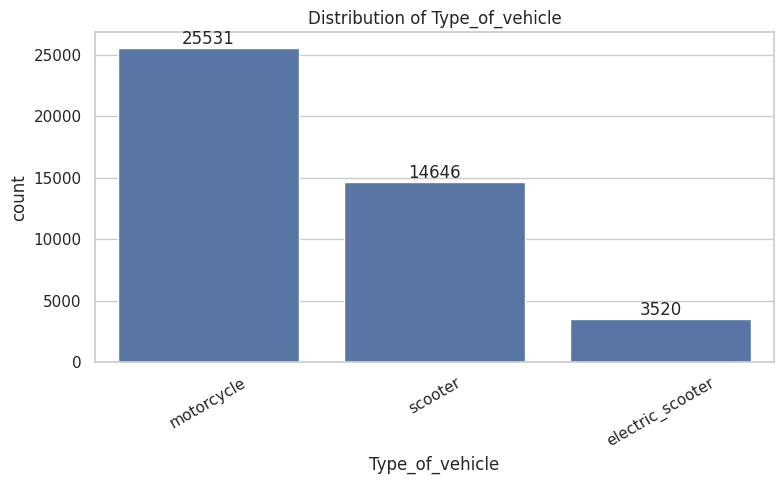

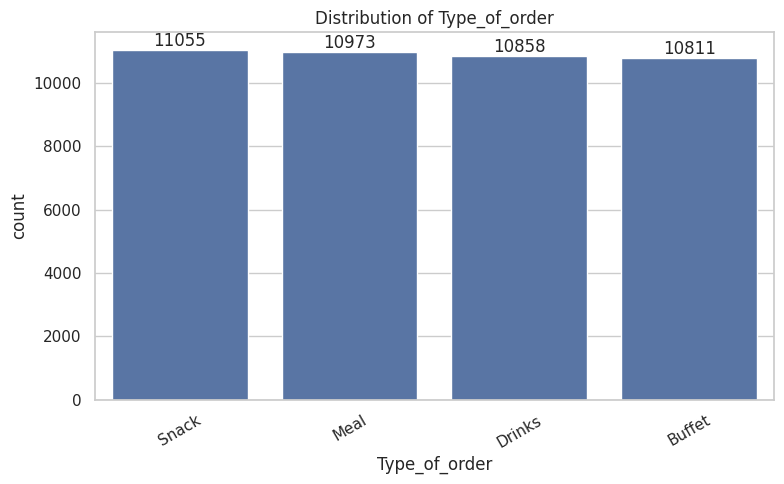

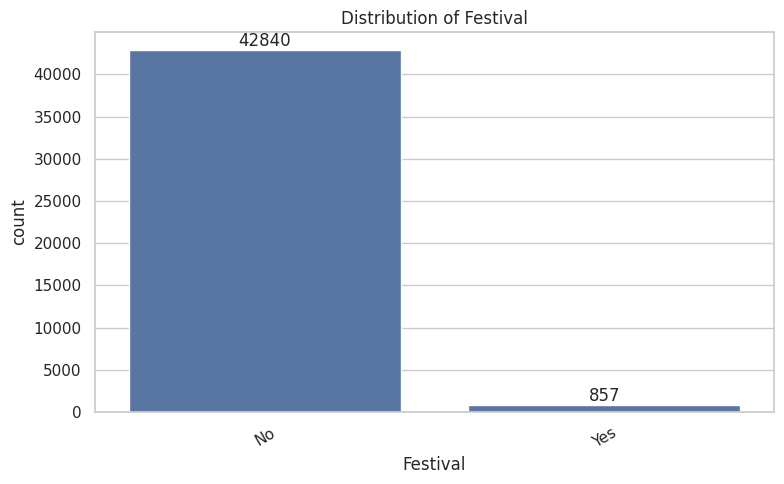

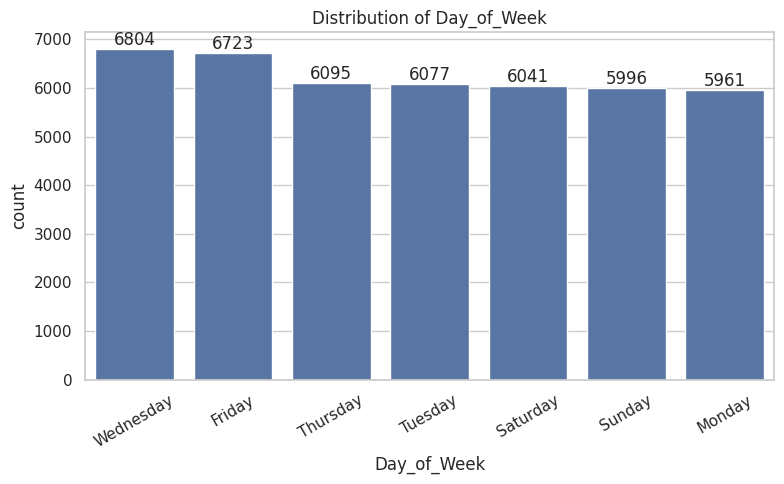

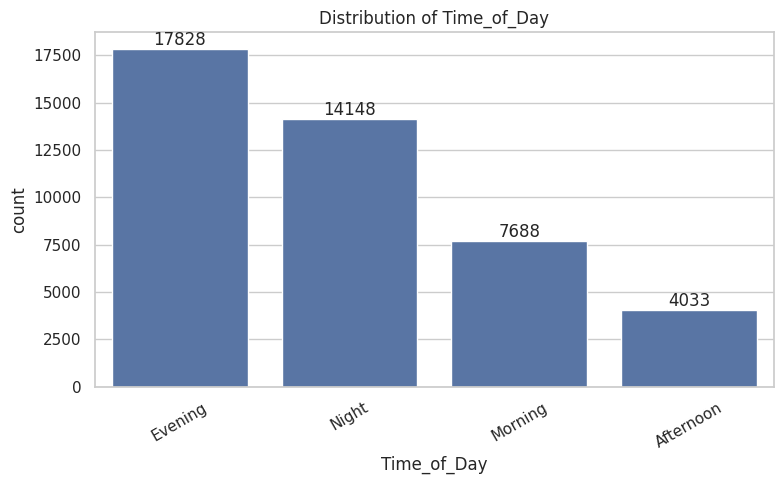

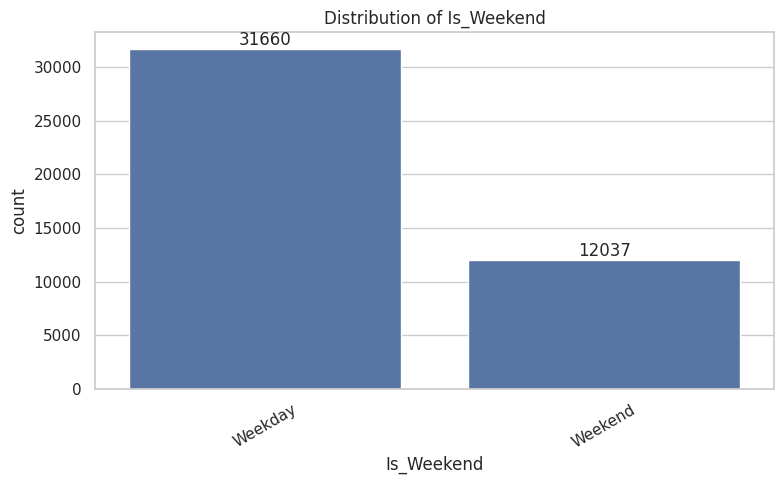

In [ ]:
for col in categorical_cols:
    plot_categorical_distribution(col)

In [ ]:
for col in categorical_cols:

    print("="*60)
    print(col)

    display(
        pd.DataFrame({
            'Count':df[col].value_counts(),
            'Percentage (%)':round(df[col].value_counts(normalize=True)*100,2)
        })
    )

Weather_conditions


,Count,Percentage (%)
Weather_conditions,,
Fog,7450,17.05
Stormy,7378,16.88
Cloudy,7312,16.73
Sandstorms,7254,16.60
Windy,7226,16.54
Sunny,7077,16.20


Road_traffic_density


,Count,Percentage (%)
Road_traffic_density,,
Low,15002,34.33
Jam,13749,31.46
Medium,10643,24.36
High,4303,9.85


City


...

,Count,Percentage (%)
Day_of_Week,,
Wednesday,6804,15.57
Friday,6723,15.39
Thursday,6095,13.95
Tuesday,6077,13.91
Saturday,6041,13.82
Sunday,5996,13.72
Monday,5961,13.64


Time_of_Day


,Count,Percentage (%)
Time_of_Day,,
Evening,17828,40.80
Night,14148,32.38
Morning,7688,17.59
Afternoon,4033,9.23


Is_Weekend


,Count,Percentage (%)
Is_Weekend,,
Weekday,31660,72.45
Weekend,12037,27.55


## Key Findings

- Delivery operations are predominantly concentrated in metropolitan areas.
- Motorcycles serve as the primary delivery vehicle.
- Delivery demand is highest during the evening and night periods.
- Road traffic is generally categorized as low or jam, with relatively few deliveries occurring under high traffic conditions.
- Order types are evenly distributed across all categories.
- Festival deliveries represent only a small fraction of the overall dataset.

# Bivariate Analysis

This section analyzes the relationship between operational factors and delivery time to identify the key drivers affecting delivery performance.

In [ ]:
# ==========================================
# Function for Average Delivery Time
# ==========================================

def plot_avg_delivery_time(column, figsize=(8,5)):

    avg = (
        df.groupby(column)['Delivery_Time']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=avg,
        x=column,
        y='Delivery_Time'
    )

    plt.title(f'Average Delivery Time by {column}')
    plt.ylabel('Average Delivery Time (Minutes)')
    plt.xlabel('')

    plt.xticks(rotation=30)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f')

    plt.tight_layout()
    plt.show()

    display(avg)

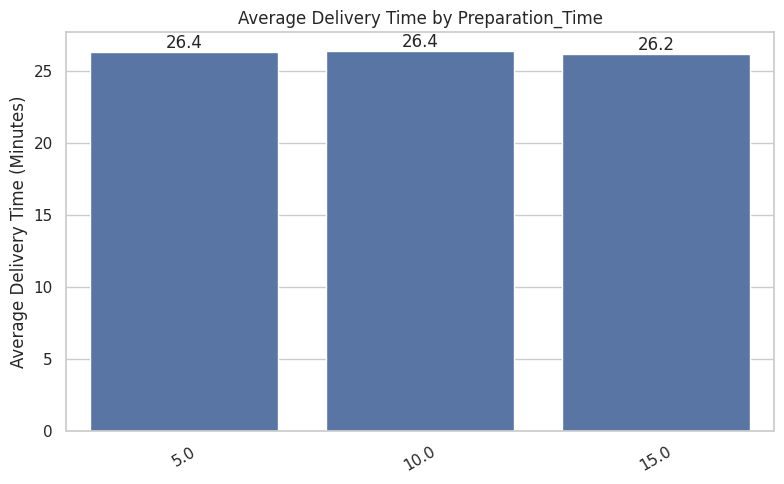

,Preparation_Time,Delivery_Time
0,10.0,26.375750
1,5.0,26.356250
2,15.0,26.160451


In [ ]:
#Preparation Time

plot_avg_delivery_time('Preparation_Time')

In [ ]:
#Distance

df['Distance_Group'] = pd.cut(
    df['Delivery_Distance_km'],
    bins=[0,5,10,15,21],
    labels=[
        '0-5 km',
        '5-10 km',
        '10-15 km',
        '15-21 km'
    ]
)

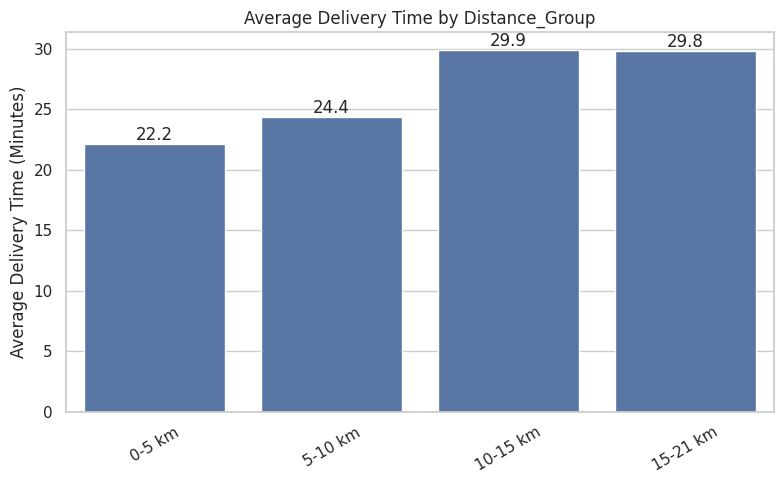

,Distance_Group,Delivery_Time
0,10-15 km,29.869436
1,15-21 km,29.838806
2,5-10 km,24.353250
3,0-5 km,22.152564


In [ ]:
plot_avg_delivery_time('Distance_Group')

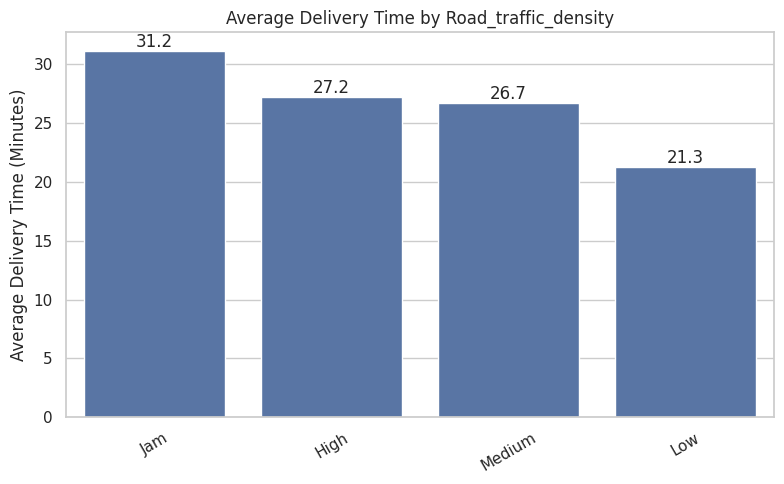

,Road_traffic_density,Delivery_Time
0,Jam,31.161612
1,High,27.202882
2,Medium,26.721695
3,Low,21.278963


In [ ]:
# Traffic
plot_avg_delivery_time('Road_traffic_density')

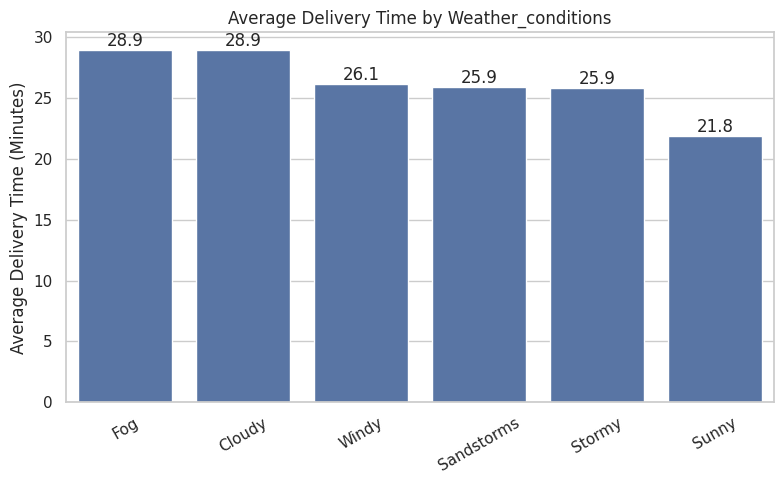

,Weather_conditions,Delivery_Time
0,Fog,28.942013
1,Cloudy,28.941056
2,Windy,26.111818
3,Sandstorms,25.896057
4,Stormy,25.856330
5,Sunny,21.843154


In [ ]:
# Weather

plot_avg_delivery_time('Weather_conditions')

In [ ]:
#Time Of Day
time_order = [
    'Morning',
    'Afternoon',
    'Evening',
    'Night'
]

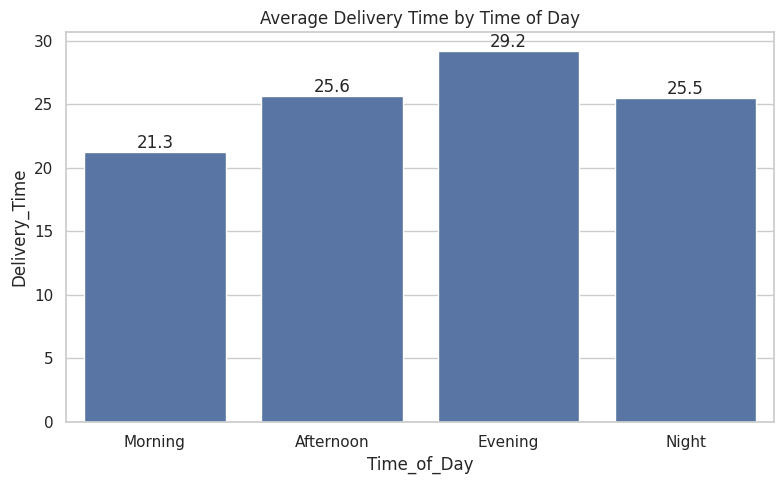

,Time_of_Day,Delivery_Time
0,Morning,21.271462
1,Afternoon,25.642450
2,Evening,29.218196
3,Night,25.534917


In [ ]:
avg = (
    df.groupby('Time_of_Day')['Delivery_Time']
      .mean()
      .reindex(time_order)
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=avg,
    x='Time_of_Day',
    y='Delivery_Time'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Average Delivery Time by Time of Day')

plt.tight_layout()

plt.show()

display(avg)

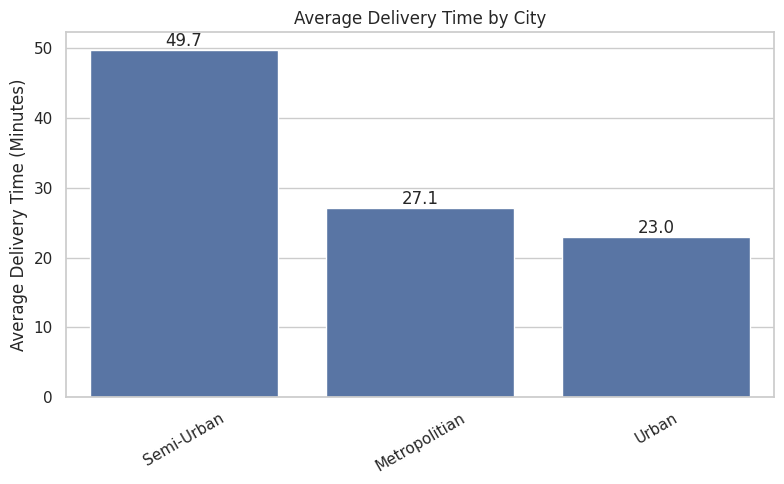

,City,Delivery_Time
0,Semi-Urban,49.737179
1,Metropolitian,27.137827
2,Urban,22.995574


In [ ]:
# City

plot_avg_delivery_time('City')

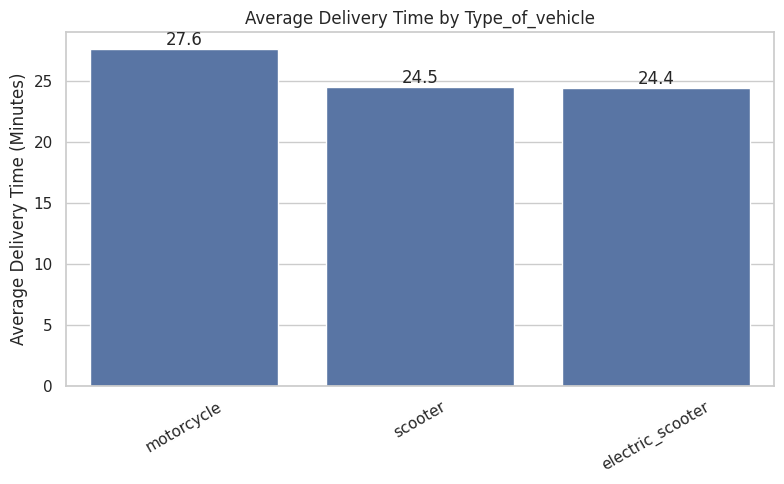

,Type_of_vehicle,Delivery_Time
0,motorcycle,27.603972
1,scooter,24.470094
2,electric_scooter,24.424716


In [ ]:
# Vehicle
plot_avg_delivery_time('Type_of_vehicle')

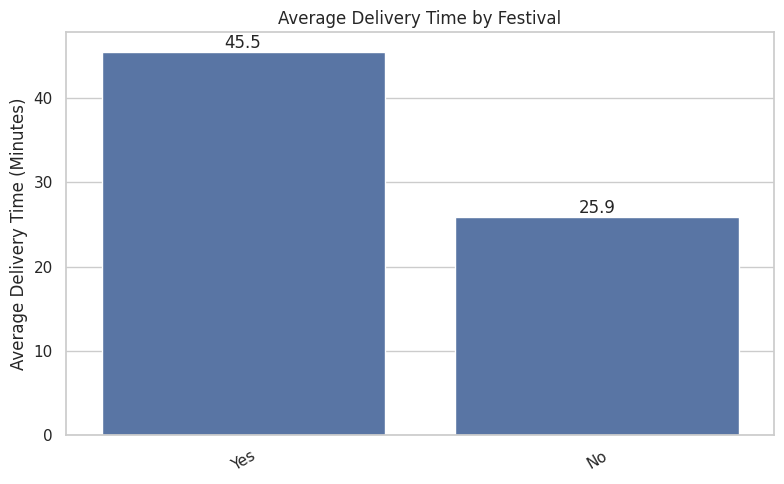

,Festival,Delivery_Time
0,Yes,45.501750
1,No,25.913305


In [ ]:
#Festival
plot_avg_delivery_time('Festival')

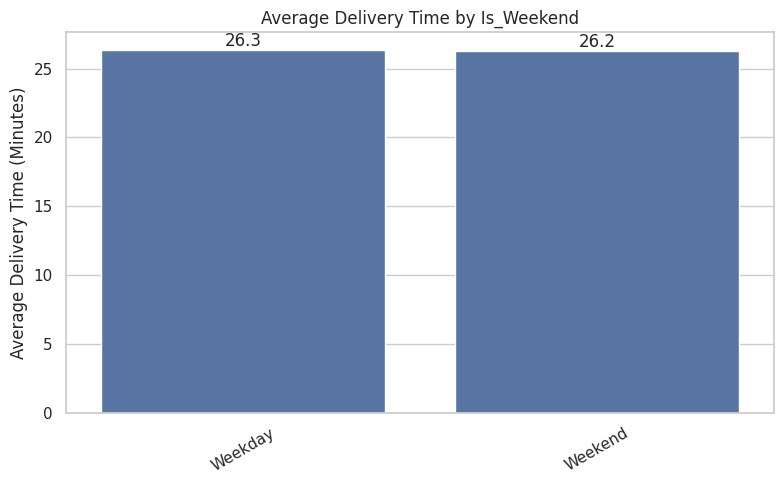

,Is_Weekend,Delivery_Time
0,Weekday,26.316140
1,Weekend,26.248401


In [ ]:
#Weekend
plot_avg_delivery_time('Is_Weekend')

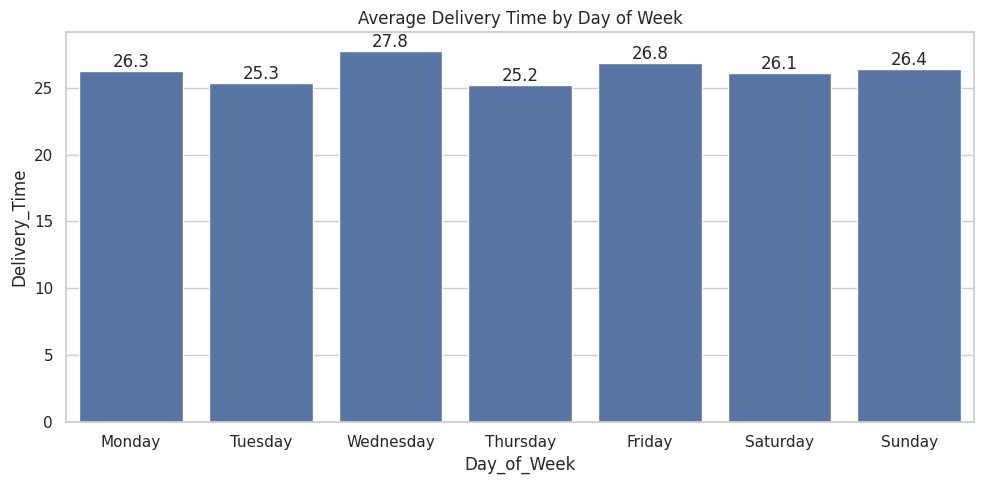

,Day_of_Week,Delivery_Time
0,Monday,26.265392
1,Tuesday,25.325983
2,Wednesday,27.754850
3,Thursday,25.200000
4,Friday,26.811989
5,Saturday,26.130608
6,Sunday,26.367078


In [ ]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

avg = (
    df.groupby('Day_of_Week')['Delivery_Time']
      .mean()
      .reindex(day_order)
      .reset_index()
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=avg,
    x='Day_of_Week',
    y='Delivery_Time'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Average Delivery Time by Day of Week')

plt.tight_layout()

plt.show()

display(avg)

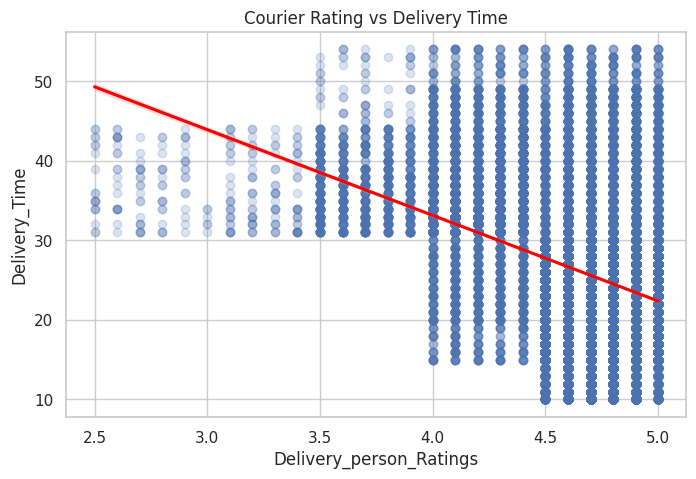

In [ ]:
# Ratinng
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Delivery_person_Ratings',
    y='Delivery_Time',
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)

plt.title('Courier Rating vs Delivery Time')

plt.show()

## Key Findings - Business Problem 1

The bivariate analysis identifies several operational factors that significantly influence delivery time.

### 1. Road Traffic Density is the strongest operational driver.

Average delivery time increases substantially under heavier traffic conditions.

- Jam : 31.16 minutes
- High : 27.20 minutes
- Medium : 26.72 minutes
- Low : 21.28 minutes

This indicates that road congestion has a significant impact on delivery efficiency.

---

### 2. Delivery Distance is positively associated with delivery time.

Longer delivery distances require more travel time.

- 0–5 km : 22.15 minutes
- 5–10 km : 24.35 minutes
- 10–15 km : 29.87 minutes
- 15–21 km : 29.84 minutes

Delivery time increases noticeably once delivery distance exceeds approximately 10 km.

---

### 3. Weather conditions affect delivery performance.

Fog and Cloudy weather are associated with the longest delivery times, while Sunny weather records the shortest average delivery time.

- Fog : 28.94 minutes
- Cloudy : 28.94 minutes
- Sunny : 21.84 minutes

This suggests that unfavorable weather conditions may slow delivery operations.

---

### 4. Festival periods significantly increase delivery time.

Average delivery time during festivals reaches 45.50 minutes, compared to only 25.91 minutes on normal days.

Although festival deliveries account for only a small proportion of observations (1.96%), they experience substantially longer delivery durations.

---

### 5. Preparation Time shows only a minor impact.

Average delivery time remains relatively similar across preparation time categories.

- 5 minutes : 26.36 minutes
- 10 minutes : 26.38 minutes
- 15 minutes : 26.16 minutes

Preparation time does not appear to be a major contributor to delivery delays in this dataset.

---

### Additional Findings

- Motorcycle deliveries record slightly longer delivery times than scooters.
- Weekday and weekend deliveries show almost identical average delivery times.
- Semi-Urban areas have the highest average delivery time; however, this segment represents less than 1% of the dataset and should be interpreted cautiously.

| Rank | Faktor                   | Alasan                                                                                                  |
| ---- | ------------------------ | ------------------------------------------------------------------------------------------------------- |
| 🥇 1 | **Road Traffic Density** | Selisih rata-rata paling jelas dan jumlah datanya besar.                                                |
| 🥈 2 | **Delivery Distance**    | Hubungan meningkat secara konsisten seiring bertambahnya jarak.                                         |
| 🥉 3 | **Weather Conditions**   | Ada perbedaan yang cukup jelas antara cuaca cerah dan berkabut/berawan.                                 |
| ⭐ 4  | **Festival**             | Dampaknya sangat besar, tetapi hanya mencakup 1,96% data sehingga lebih cocok sebagai insight tambahan. |
| ⭐ 5  | **Preparation Time**     | Tidak menunjukkan perbedaan berarti, sehingga bukan faktor utama dalam dataset ini.                     |


# Operational Performance Analysis

#1. Heatmap

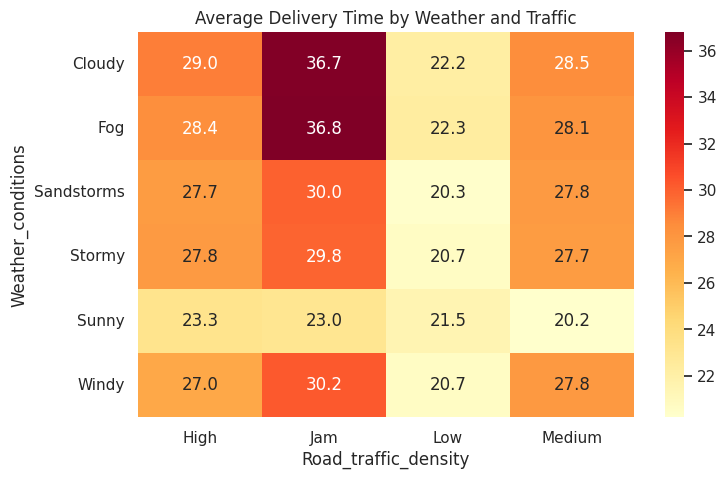

In [ ]:
performance = df.pivot_table(
    index='Weather_conditions',
    columns='Road_traffic_density',
    values='Delivery_Time',
    aggfunc='mean'
)

plt.figure(figsize=(8,5))

sns.heatmap(
    performance,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Average Delivery Time by Weather and Traffic")

plt.show()

#Key Findings
1. Traffic congestion merupakan faktor operasional yang paling berpengaruh terhadap lamanya pengiriman.
2. Delivery time meningkat secara konsisten pada kondisi Jam, hampir di seluruh kondisi cuaca.
3. Kombinasi Fog + Jam (36.8 menit) menghasilkan rata-rata delivery time terlama.
4. Sebaliknya, kondisi Sunny + Medium/Low Traffic (~20–23 menit) memberikan performa pengiriman tercepat.

#2. City vs Weather

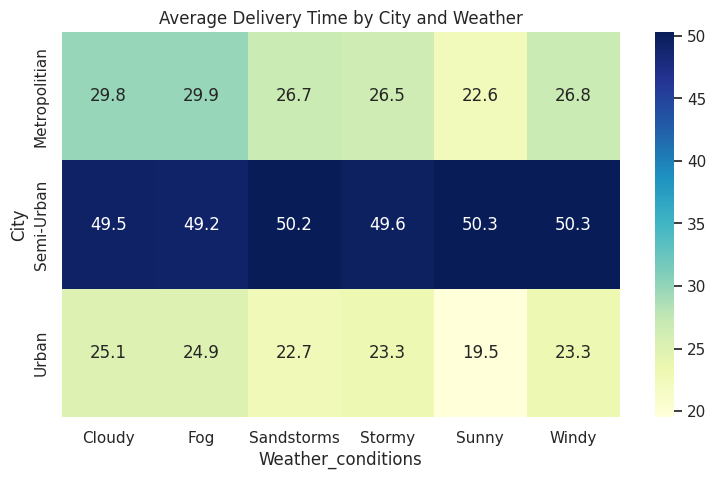

In [ ]:
city_weather = df.pivot_table(
    index='City',
    columns='Weather_conditions',
    values='Delivery_Time',
    aggfunc='mean'
)

plt.figure(figsize=(9,5))

sns.heatmap(
    city_weather,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Average Delivery Time by City and Weather")

plt.show()

#Key Findings
1. Semi-Urban memiliki delivery time paling tinggi pada seluruh kondisi cuaca (sekitar 49–50 menit).
2. Metropolitan dan Urban memiliki performa yang jauh lebih baik dibanding Semi-Urban.
3. Cuaca hanya memberikan perubahan kecil pada Metropolitan dan Urban, sedangkan perbedaan kota memberikan pengaruh yang jauh lebih besar.
4. Hal ini mengindikasikan bahwa karakteristik wilayah memiliki dampak lebih besar dibanding variasi cuaca.

#Catatan saat presentasi:

Semi-Urban hanya sekitar 0.36% dari seluruh data, sehingga insight ini tetap valid tetapi tidak boleh digeneralisasi sebagai kondisi mayoritas.

#3. Vehicle vs Traffic

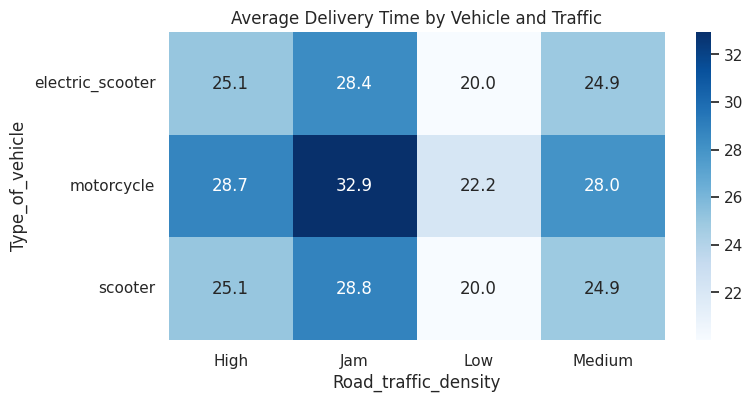

In [ ]:
vehicle = df.pivot_table(
    index='Type_of_vehicle',
    columns='Road_traffic_density',
    values='Delivery_Time',
    aggfunc='mean'
)

plt.figure(figsize=(8,4))

sns.heatmap(
    vehicle,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Average Delivery Time by Vehicle and Traffic")

plt.show()

#Key Findings
1. Traffic tetap menjadi faktor dominan terlepas dari jenis kendaraan.
2. Motorcycle memiliki delivery time paling tinggi ketika menghadapi kondisi macet (32.9 menit).
3. Scooter dan Electric Scooter menunjukkan performa yang hampir sama pada seluruh tingkat traffic.
4. Pergantian jenis kendaraan saja kemungkinan tidak akan memberikan peningkatan besar tanpa mengatasi kemacetan.

#4. Distance Group vs Traffic

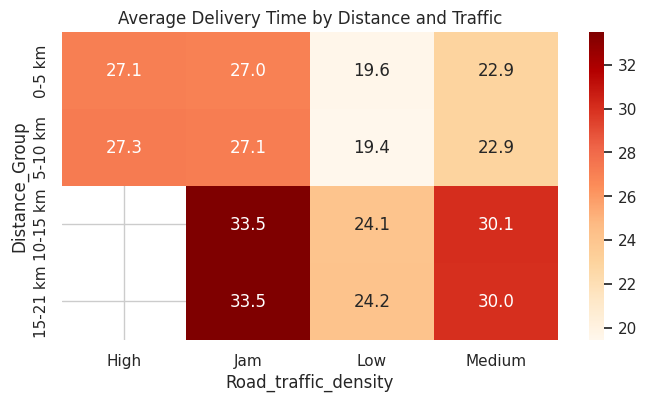

In [ ]:
distance_traffic = df.pivot_table(
    index='Distance_Group',
    columns='Road_traffic_density',
    values='Delivery_Time',
    aggfunc='mean'
)

plt.figure(figsize=(8,4))

sns.heatmap(
    distance_traffic,
    annot=True,
    fmt=".1f",
    cmap="OrRd"
)

plt.title("Average Delivery Time by Distance and Traffic")

plt.show()

#Key Findings
1. Delivery time meningkat seiring bertambahnya jarak pengiriman.
2. Dampak kemacetan menjadi semakin besar pada pengiriman jarak jauh.
3. Untuk jarak 15–21 km, kondisi Jam menghasilkan delivery time sekitar 33.5 menit, jauh lebih tinggi dibanding traffic rendah (24.2 menit).
4. Kombinasi jarak jauh + kemacetan merupakan faktor operasional utama yang menyebabkan keterlambatan pengiriman.

#Kesimpulan Business Problem 2

#Key Findings
1. Road traffic density merupakan faktor operasional yang paling konsisten meningkatkan delivery time.
2. Long-distance deliveries become substantially slower under heavy traffic conditions.
3. Weather contributes to longer delivery times, but its impact is smaller than traffic congestion.
4. Semi-Urban areas exhibit the longest average delivery times across all weather conditions, although this segment represents only a small portion of total orders.
5. Vehicle type has relatively limited influence compared with traffic density and delivery distance.

# Business Problem 3

Which operational segments should be prioritized to improve delivery efficiency?

In [ ]:
#Priority Matrix
priority = pd.DataFrame({
    'Priority': [
        'High',
        'High',
        'Medium',
        'Medium',
        'Low'
    ],
    'Operational Segment': [
        'Traffic Congestion',
        'Long Distance Deliveries',
        'Adverse Weather Conditions',
        'Festival Deliveries',
        'Vehicle Type'
    ],
    'Reason': [
        'Largest and most consistent increase in delivery time.',
        'Delivery time increases substantially for deliveries above 10 km.',
        'Fog and cloudy weather moderately increase delivery duration.',
        'Festival deliveries are much slower but represent only a small proportion of total orders.',
        'Vehicle type shows relatively small differences compared with other factors.'
    ]
})

priority

,Priority,Operational Segment,Reason
0,High,Traffic Congestion,Largest and most consistent increase in delivery time.
1,High,Long Distance Deliveries,Delivery time increases substantially for deliveries above 10 km.
2,Medium,Adverse Weather Conditions,Fog and cloudy weather moderately increase delivery duration.
3,Medium,Festival Deliveries,Festival deliveries are much slower but represent only a small proportion of total orders.
4,Low,Vehicle Type,Vehicle type shows relatively small differences compared with other factors.


## Key Findings - Business Problem 3

Based on the exploratory analysis, operational improvement efforts should focus on the factors with the greatest impact on delivery performance.

### Priority 1 – Traffic Congestion

Traffic congestion consistently produces the longest delivery times across nearly all operational conditions.

Improving route optimization and dispatching during congested periods is expected to deliver the greatest operational impact.

---

### Priority 2 – Long Distance Deliveries

Deliveries exceeding 10 km require substantially longer delivery times, particularly under congested traffic conditions.

Long-distance deliveries should be optimized through delivery zone planning or smarter courier assignment.

---

### Priority 3 – Weather Conditions

Foggy and cloudy weather moderately increase delivery duration.

Although weather cannot be controlled, proactive operational planning can help reduce its impact.

---

### Priority 4 – Festival Operations

Festival deliveries experience the highest average delivery time.

However, festival orders account for only a small proportion of the dataset, making them a secondary operational priority.

---

### Priority 5 – Vehicle Type

Vehicle type shows relatively small differences in delivery performance.

Operational improvements should therefore focus on traffic management and delivery distance rather than changing vehicle types.